<h1 style="text-align: center; background-color: #1e86cc; border-radius: 30px; padding: 10px;">COSC2753 - Machine Learning</h1>
<h2 style="text-align: center;">Assignment 1 - Chatbot Data Analysis</h2>
<h3 style="text-align: center;">Author: Nguyen Gia Khang</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import math

In [2]:
chatbot_data = pd.read_csv('./inputs/train.csv')

In [3]:
chatbot_data

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,...,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,...,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,...,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,...,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,...,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2066,2067,47.7,12.0,61,2006.0,0,578,596,560.0,36,...,7.33,83.0,17.6,59.67,11731746.0,7.2,7.1,0.456,3.240370,7.306873
2067,2068,46.0,10.0,61,2005.0,0,64,66,62.0,39,...,8.18,83.0,18.2,480.66,11421984.0,7.3,7.2,0.443,3.193744,6.674413
2068,2069,46.2,10.0,61,2004.0,0,69,70,68.0,41,...,6.93,84.0,18.4,422.39,111249.0,7.4,7.3,0.433,3.162278,7.191646
2069,2070,47.1,11.0,61,2003.0,0,611,574,648.0,43,...,6.56,85.0,18.6,423.67,1824125.0,7.4,7.4,0.424,3.130495,8.045096


In [4]:
chatbot_data.head()

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
0,1,54.5,19.0,146,2007.0,0,291,306,276.0,85,...,8.70,58.0,0.1,28.33,257798.0,19.3,19.5,0.396,2.810694,1.152688
1,2,58.5,23.0,146,2006.0,0,293,286,300.0,87,...,8.79,5.0,0.1,245.44,24118979.0,19.5,19.7,0.381,2.607681,1.140279
2,3,53.9,18.0,146,2005.0,0,295,326,264.0,87,...,8.82,41.0,0.1,222.58,2364851.0,19.7,19.9,0.373,2.549510,1.127205
3,4,58.4,22.0,146,2004.0,0,3,2,4.0,88,...,7.76,36.0,0.1,210.39,21979923.0,19.9,2.2,0.341,2.489980,1.114043
4,5,55.2,19.0,146,2003.0,0,316,312,320.0,88,...,7.80,33.0,0.1,131.60,2966463.0,2.1,2.4,0.340,2.428992,1.100471


In [5]:
chatbot_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2071 entries, 0 to 2070
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   RecordID                  2071 non-null   int64  
 1   TARGET_Capacity           2070 non-null   float64
 2   CaseCount                 2069 non-null   float64
 3   Country                   2071 non-null   int64  
 4   Year                      2070 non-null   float64
 5   Status                    2071 non-null   int64  
 6   SystemFailureRate         2071 non-null   int64  
 7   ModelFailureRate-T        2071 non-null   int64  
 8   ModelFailureRate-NT       2070 non-null   float64
 9   InferenceLatency          2071 non-null   int64  
 10  ComputeUtilizationRate    2071 non-null   float64
 11  AIInfraExpPercent         2071 non-null   float64
 12  SecurityBreachIncidents   2071 non-null   int64  
 13  IntegrationEfficiency     2071 non-null   float64
 14  UptimeReliabilityIn

In [6]:
chatbot_data[chatbot_data.isnull().any(axis=1)]

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
88,89,77.4,41.0,15,NaN,0,132,128,136.0,1,...,4.31,88.0,0.1,3515.55,293356.0,2.0,2.1,0.707,3.420526,17.616456
169,170,73.0,37.0,176,2008.0,0,243,236,NaN,1,...,6.34,99.0,0.1,4310.00,964924.0,2.2,2.4,0.723,3.820995,160.517396
231,232,65.8,30.0,117,2010.0,0,234,228,240.0,1,...,6.58,96.0,0.4,2010.60,NaN,17.1,17.8,0.000,3.240370,1.318258
297,298,73.7,38.0,170,2008.0,1,161,164,158.0,1,...,6.67,95.0,0.1,5054.71,76122.0,2.2,2.2,0.750,NaN,108.751441
313,314,52.0,16.0,27,2008.0,0,32,34,30.0,47,...,6.58,86.0,2.0,473.35,13829177.0,1.0,9.6,0.325,2.167948,NaN
314,315,53.4,17.0,27,2007.0,0,313,316,310.0,48,...,NaN,82.0,2.3,52.64,1342193.0,1.3,9.8,0.000,2.073644,24.966688
318,319,55.6,NaN,27,2003.0,0,344,364,324.0,48,...,4.85,62.0,3.6,263.75,11944587.0,11.2,1.8,0.000,1.870829,21.890510
330,331,NaN,22.0,95,2007.0,0,369,386,352.0,24,...,9.84,87.0,4.3,17.44,7423289.0,8.2,8.3,0.286,2.366432,31.840819
942,943,73.0,NaN,43,2004.0,0,167,160,174.0,1,...,4.86,99.0,2.3,4028.08,2695446.0,2.0,1.8,0.690,3.420526,15.776089
1190,1191,75.8,40.0,111,2012.0,0,73,74,72.0,0,...,7.93,96.0,0.1,709.85,367.0,14.0,14.1,0.653,3.405877,NaN


In [7]:
print(f"Duplicate rows: {chatbot_data.duplicated().sum()}")

Duplicate rows: 0


In [8]:
chatbot_data.describe(include="all")

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
count,2071.000000,2070.000000,2069.000000,2071.000000,2070.000000,2071.000000,2071.000000,2071.000000,2070.000000,2071.000000,...,2070.000000,2071.000000,2071.000000,2071.000000,2.070000e+03,2071.000000,2071.000000,2071.000000,2070.000000,2069.000000
mean,1036.000000,69.280000,33.333011,95.360212,2009.518841,0.192178,163.198938,161.908257,163.717874,33.079672,...,5.883382,82.753259,1.632883,7350.672269,1.204323e+07,4.955625,4.977306,0.609551,3.372308,41.235455
std,597.990524,9.481274,9.488045,54.861641,4.615248,0.506724,119.787231,119.442235,118.813864,135.832868,...,2.555490,23.130969,4.782325,15220.687350,6.393286e+07,4.728884,4.785532,0.216532,0.590938,52.618343
min,1.000000,37.300000,1.000000,0.000000,2002.000000,0.000000,1.000000,0.000000,2.000000,0.000000,...,0.370000,2.000000,0.100000,0.000000,3.400000e+01,0.100000,0.100000,0.000000,0.000000,0.146228
25%,518.500000,63.000000,27.000000,50.000000,2006.000000,0.000000,74.000000,74.000000,74.000000,0.000000,...,4.185000,78.000000,0.100000,413.730000,1.274450e+05,1.600000,1.500000,0.463000,3.065942,2.038296
50%,1036.000000,71.200000,35.000000,94.000000,2010.000000,0.000000,144.000000,142.000000,144.000000,3.000000,...,5.640000,93.000000,0.100000,1397.330000,6.525915e+05,3.200000,3.300000,0.655000,3.449638,16.085911
75%,1553.500000,76.000000,40.000000,144.000000,2014.000000,0.000000,228.000000,228.000000,230.000000,22.000000,...,7.430000,97.000000,0.800000,5811.295000,5.373518e+06,7.400000,7.400000,0.769500,3.741657,63.144118
max,2071.000000,92.700000,57.000000,192.000000,2017.000000,15.000000,840.000000,704.000000,722.000000,1800.000000,...,17.600000,99.000000,50.600000,133473.470000,1.293859e+09,30.000000,28.600000,0.948000,4.381780,321.087408


Define rows with Status different from 0 and 1

In [9]:
rows_with_status_not_0_or_1 = chatbot_data[~chatbot_data['Status'].isin([0, 1])]
rows_with_status_not_0_or_1

,RecordID,TARGET_Capacity,CaseCount,Country,Year,Status,SystemFailureRate,ModelFailureRate-T,ModelFailureRate-NT,InferenceLatency,...,AIDevExpPercent,PatchCoverageRate,SystemVulnerabilityScore,GlobalAdoptionIndex,ActiveUserBase,TeenQueryEfficiency,ChildQueryEfficiency,FundingDiversityIndex,DatasetDiversityScore,Complexity
441,442,77.7,42.0,151,2008.0,15,113,116,110.0,0,...,6.95,96.0,0.1,12727.03,444.0,1.8,1.8,0.783,3.72827,141.713076


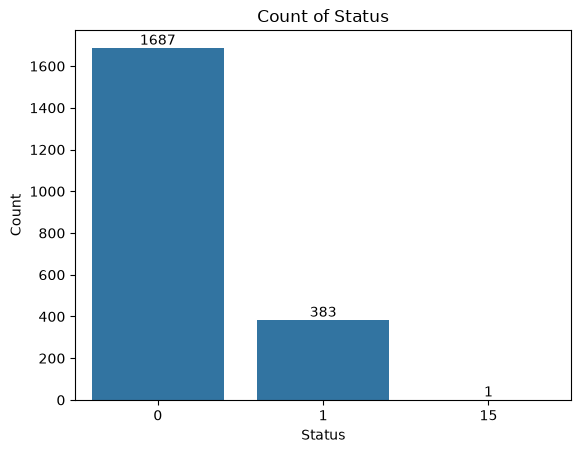

In [10]:
ax = sns.countplot(data=chatbot_data, x="Status")
plt.title("Count of Status")
plt.xlabel("Status")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

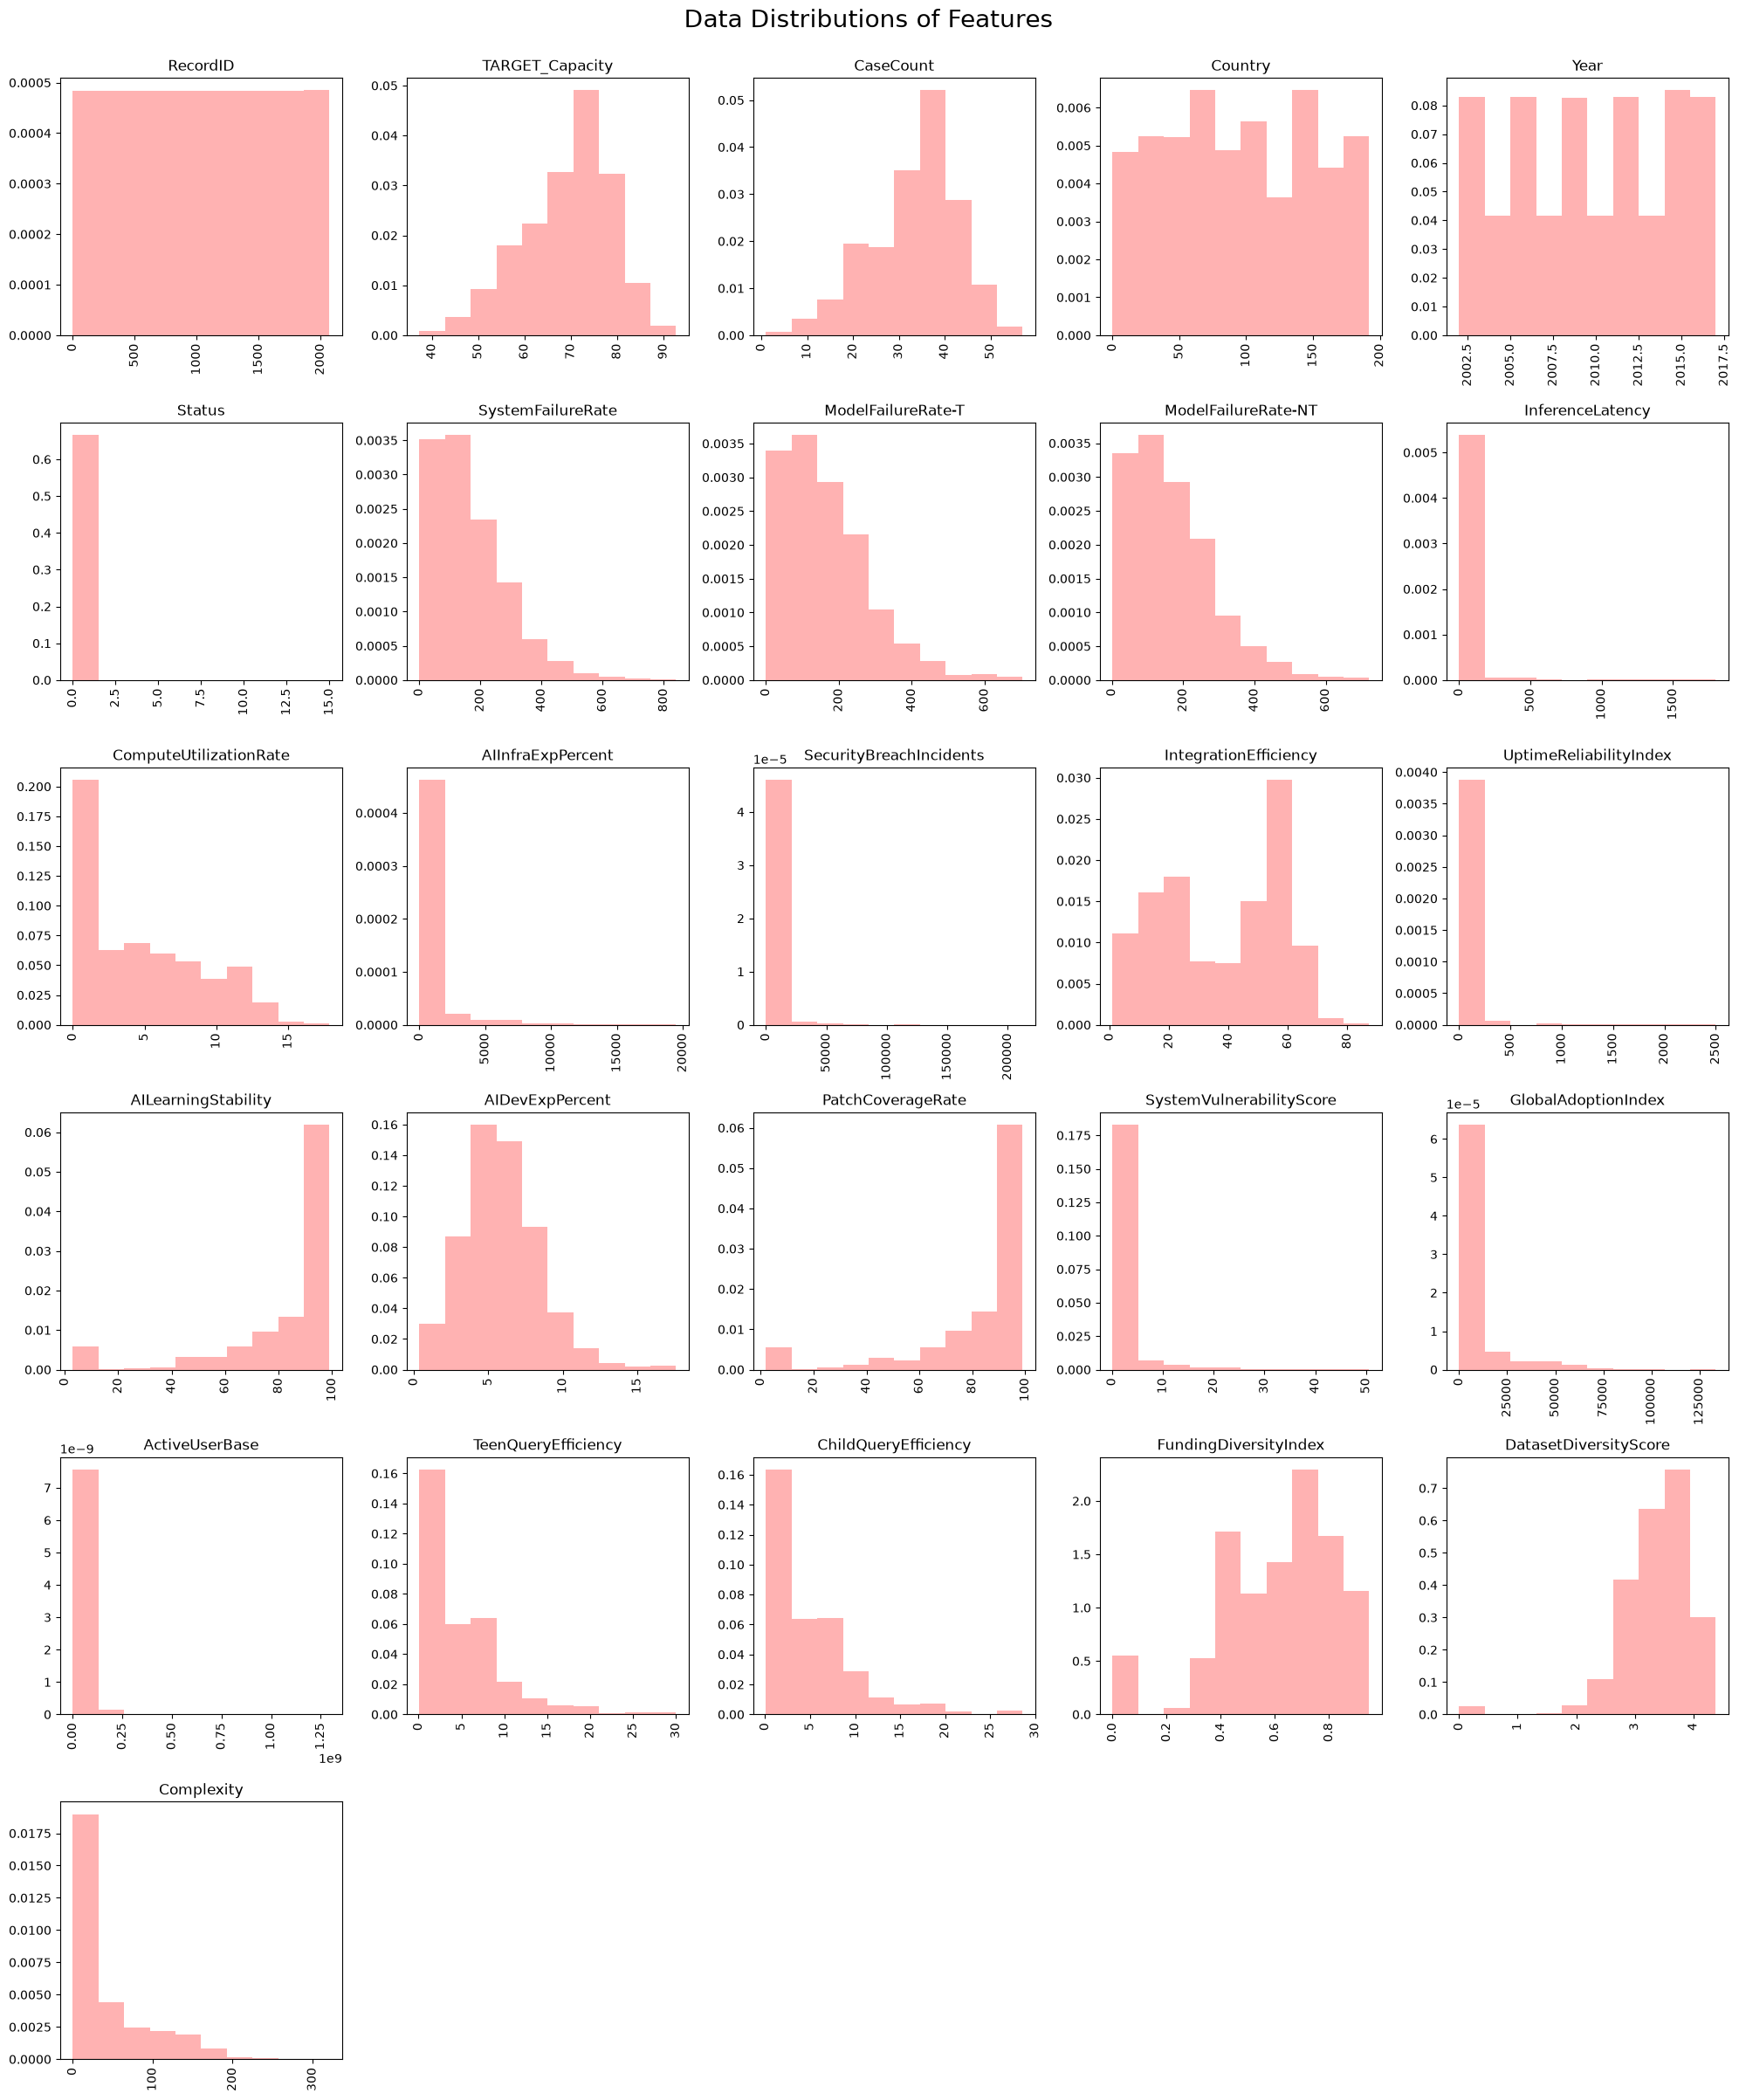

In [11]:
plt.figure(figsize=(20,24))
for i, col in enumerate(chatbot_data.columns):
    plt.subplot(6,5,i+1)
    plt.hist(chatbot_data[col], alpha=0.3, color='r', density=True)
    plt.title(col)
    plt.xticks(rotation='vertical')

plt.suptitle("Data Distributions of Features", y=1, fontsize=20)
plt.tight_layout()
plt.show()

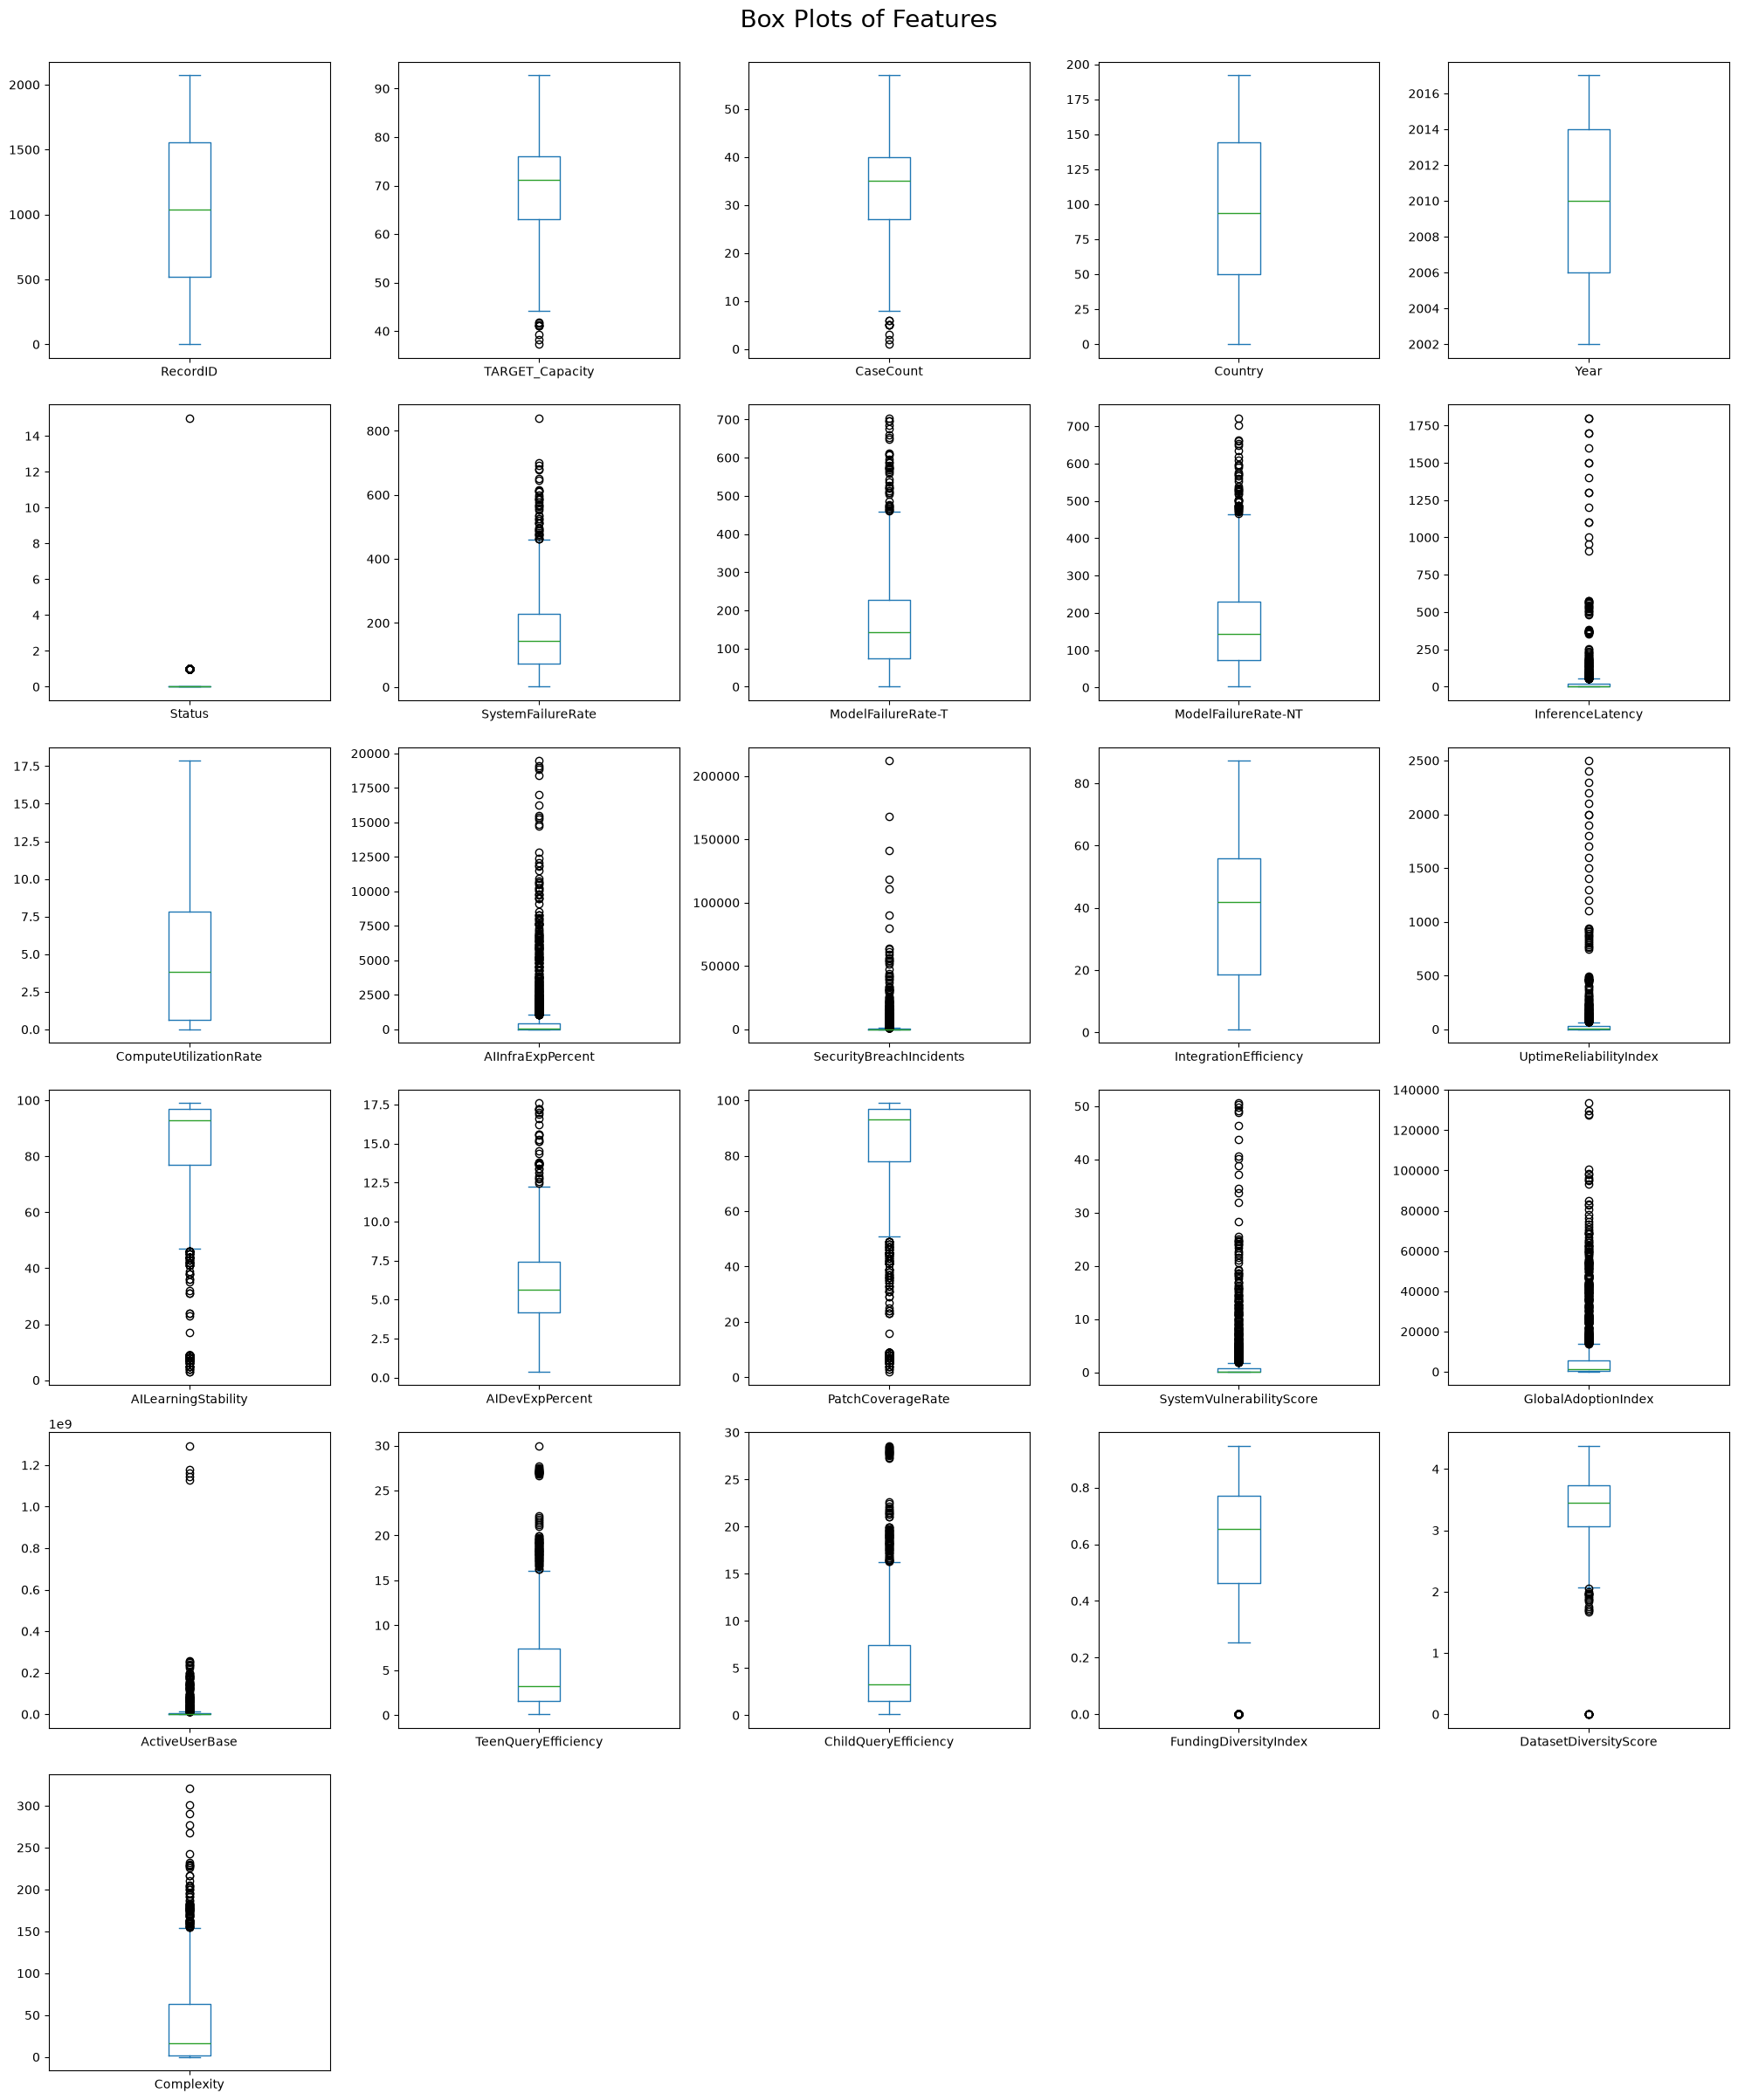

In [12]:
chatbot_data.plot(kind='box', subplots=True, layout=(6,5), figsize=(20,24), sharex=False, sharey=False)

plt.suptitle("Box Plots of Features", y=1, fontsize=20)
plt.tight_layout()
plt.show()

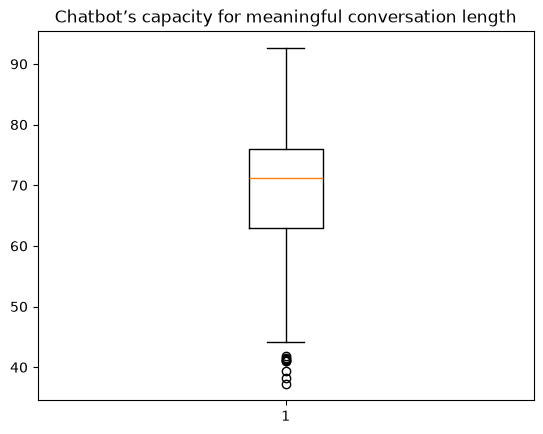

In [13]:
plt.boxplot(chatbot_data['TARGET_Capacity'].dropna())
plt.title('Chatbot’s capacity for meaningful conversation length')
plt.show()

In [14]:
def analyze_outliers_iqr(col, df):
    """
    Analyze outliers in a column using the IQR (Tukey's) method.

    Parameters:
    col : str
        Column name to analyze
    df : pandas DataFrame
        DataFrame containing the data (defaults to global df if not provided)
    """

    # 1st quartile (25%)
    q1 = np.nanpercentile(df[col], 25)
    # 3rd quartile (75%)
    q3 = np.nanpercentile(df[col], 75)

    # Interquartile range (IQR)
    iqr = q3 - q1

    min_val = q1 - (iqr * 1.5)
    max_val = q3 + (iqr * 1.5)

    outliers_cnt = len(np.where((df[col] > max_val) | (df[col] < min_val))[0])
    rate = round(outliers_cnt / len(df[col]) * 100, 2)
    print(f"{col}'s outliers: {outliers_cnt} ({rate}%)")

    return outliers_cnt, rate

In [15]:
for col in chatbot_data.columns:
    analyze_outliers_iqr(col, df=chatbot_data)

RecordID's outliers: 0 (0.0%)
TARGET_Capacity's outliers: 9 (0.43%)
CaseCount's outliers: 9 (0.43%)
Country's outliers: 0 (0.0%)
Year's outliers: 0 (0.0%)
Status's outliers: 384 (18.54%)
SystemFailureRate's outliers: 43 (2.08%)
ModelFailureRate-T's outliers: 42 (2.03%)
ModelFailureRate-NT's outliers: 44 (2.12%)
InferenceLatency's outliers: 201 (9.71%)
ComputeUtilizationRate's outliers: 0 (0.0%)
AIInfraExpPercent's outliers: 300 (14.49%)
SecurityBreachIncidents's outliers: 378 (18.25%)
IntegrationEfficiency's outliers: 0 (0.0%)
UptimeReliabilityIndex's outliers: 241 (11.64%)
AILearningStability's outliers: 183 (8.84%)
AIDevExpPercent's outliers: 33 (1.59%)
PatchCoverageRate's outliers: 206 (9.95%)
SystemVulnerabilityScore's outliers: 366 (17.67%)
GlobalAdoptionIndex's outliers: 295 (14.24%)
ActiveUserBase's outliers: 287 (13.86%)
TeenQueryEfficiency's outliers: 78 (3.77%)
ChildQueryEfficiency's outliers: 83 (4.01%)
FundingDiversityIndex's outliers: 108 (5.21%)
DatasetDiversityScore's ou

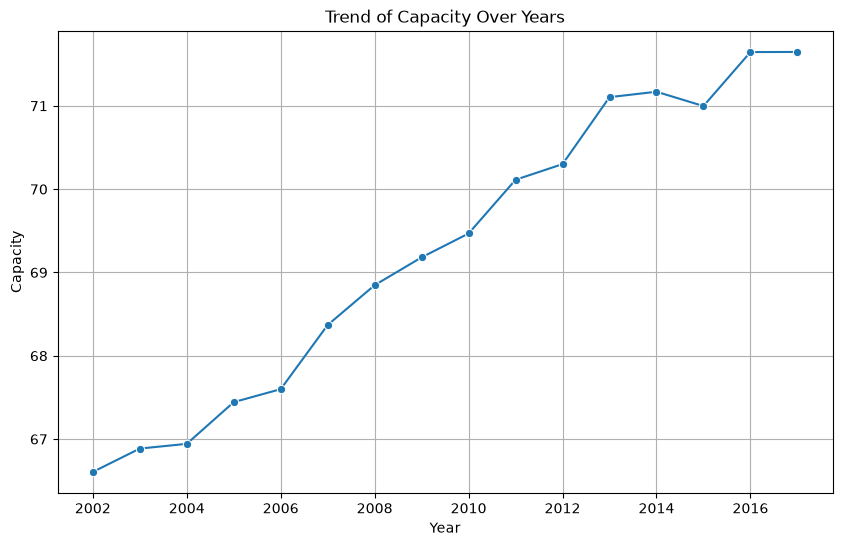

In [16]:
# Group by year and calculate mean life expectancy
trend_data = chatbot_data.groupby("Year")["TARGET_Capacity"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=trend_data, x="Year", y="TARGET_Capacity", marker="o")
plt.title("Trend of Capacity Over Years")
plt.ylabel("Capacity")
plt.xlabel("Year")
plt.grid(True)
plt.show()

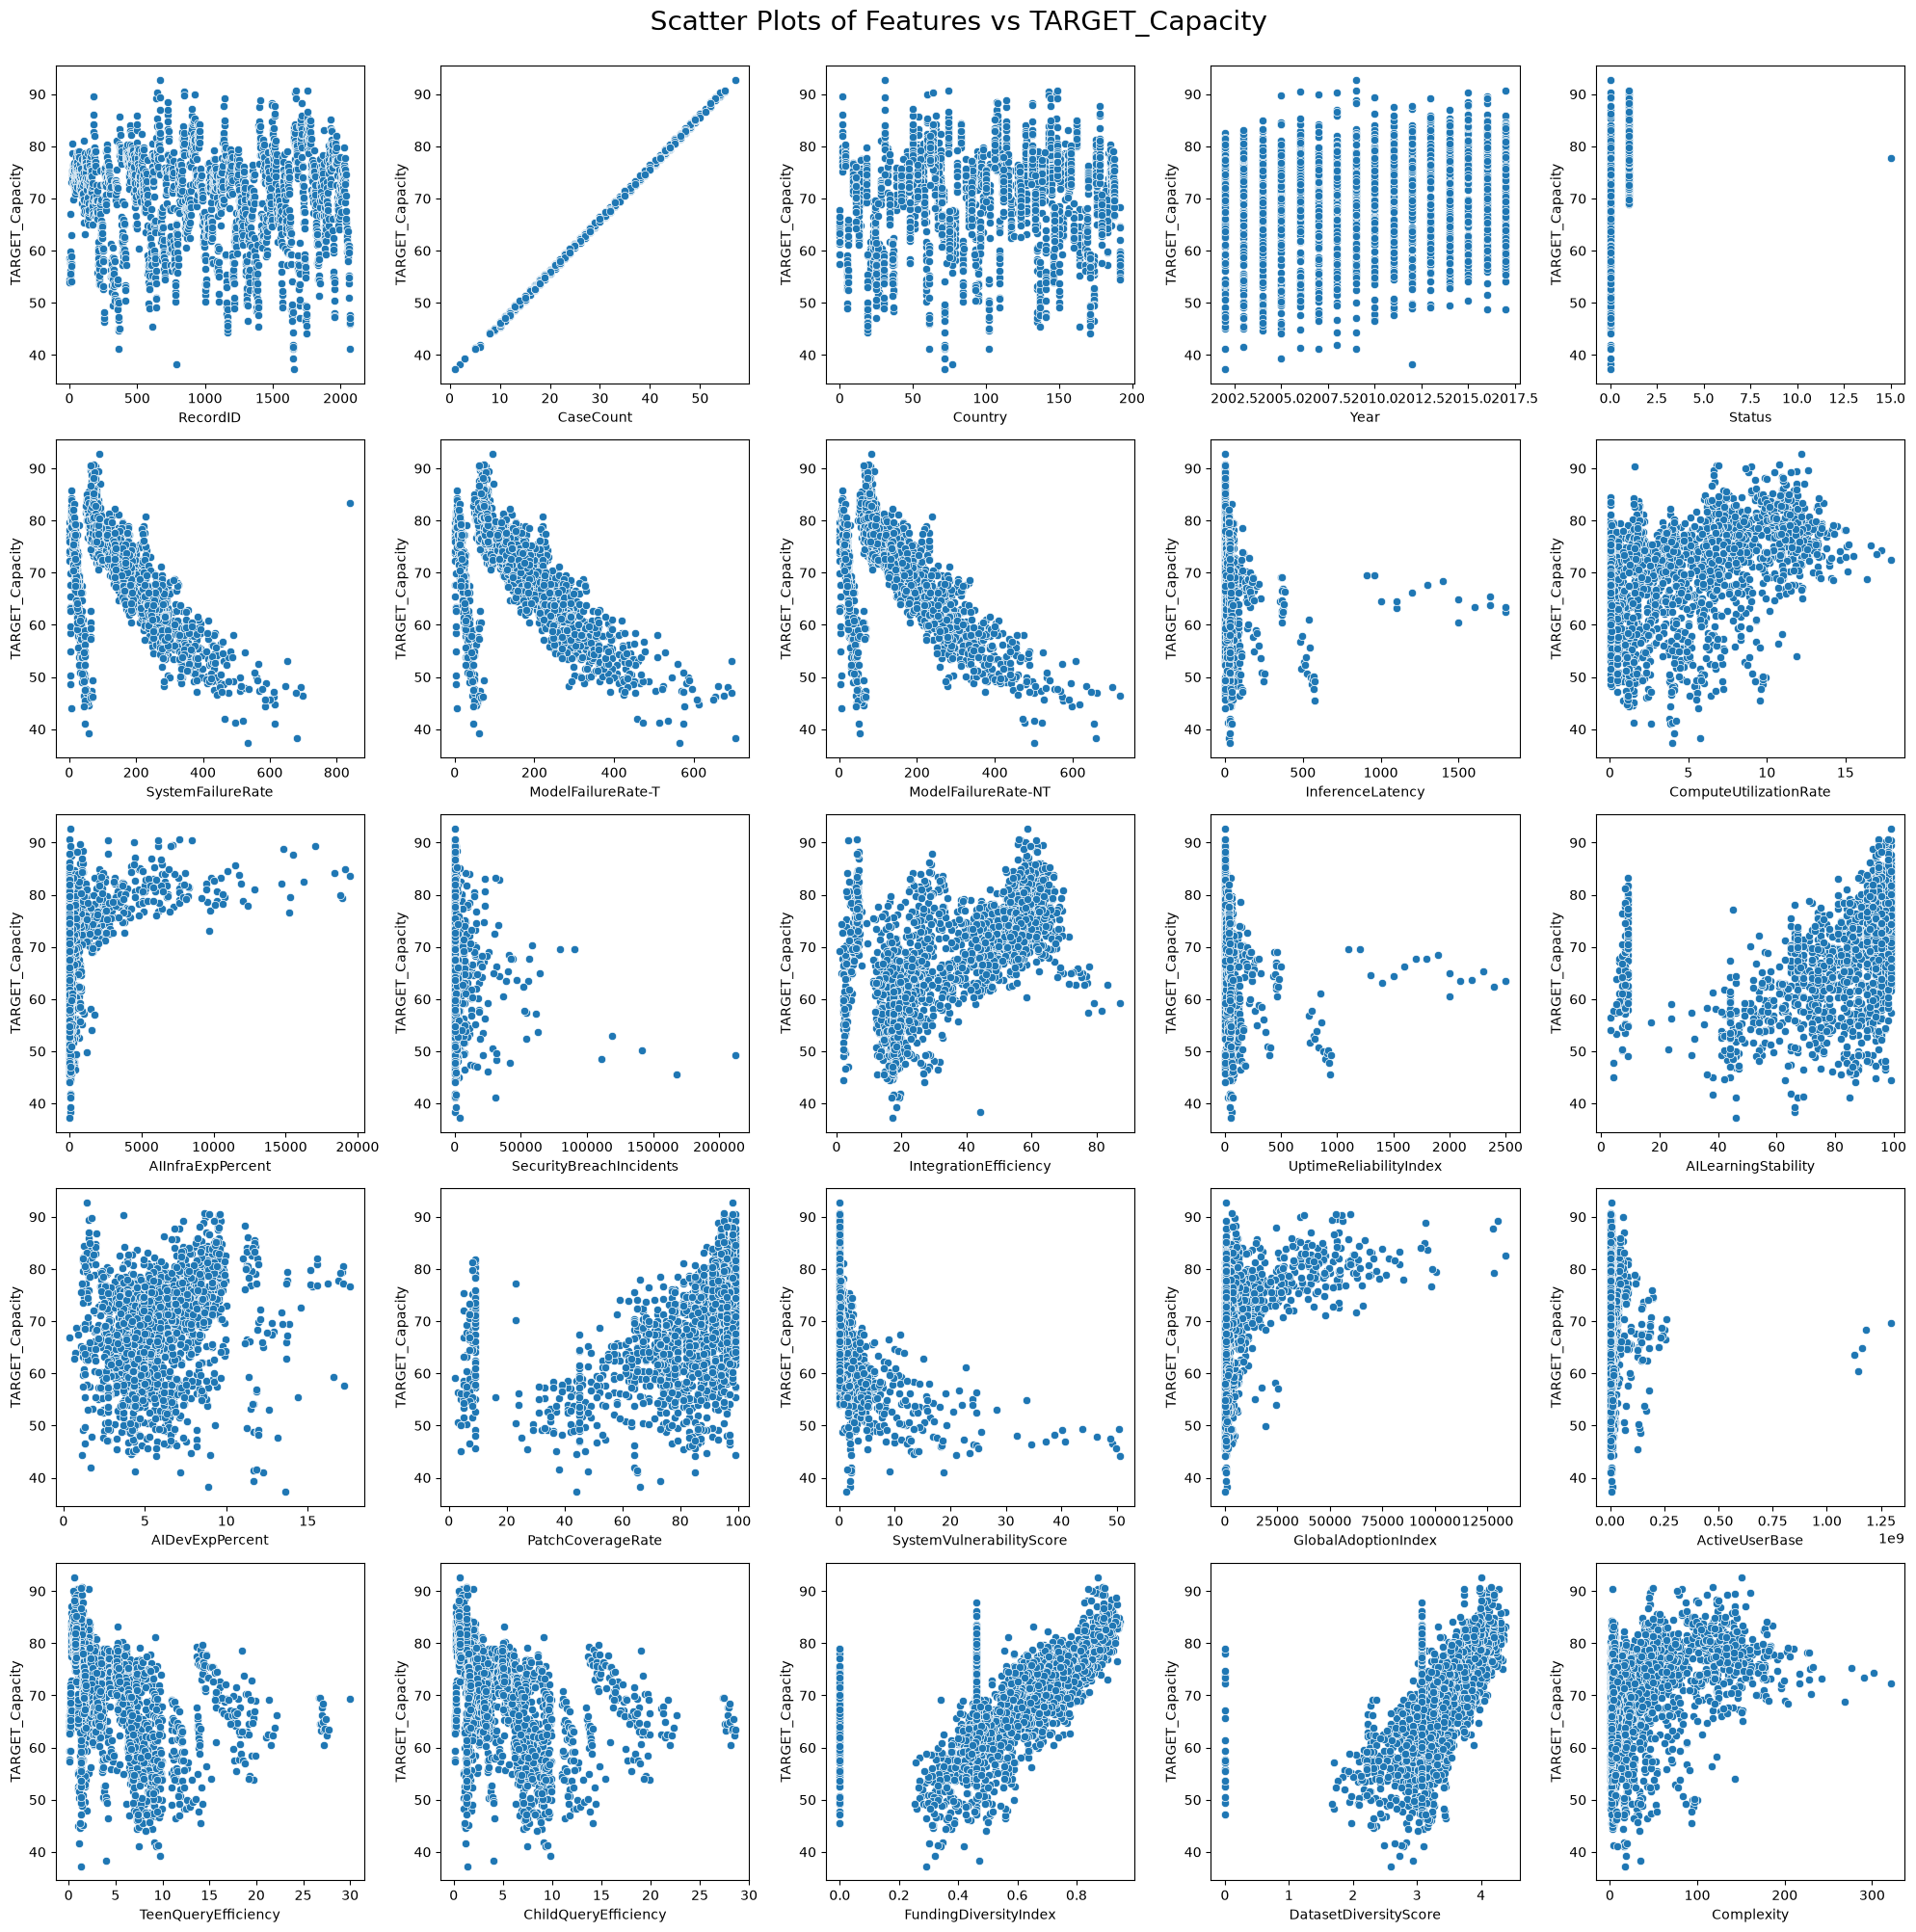

In [17]:
target = "TARGET_Capacity"
features = [col for col in chatbot_data.select_dtypes(include="number").columns if col != target]

n = len(features)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.scatterplot(data=chatbot_data, x=feature, y=target, ax=axes[i])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Scatter Plots of Features vs TARGET_Capacity", y=1, fontsize=20)
plt.tight_layout()
plt.show()

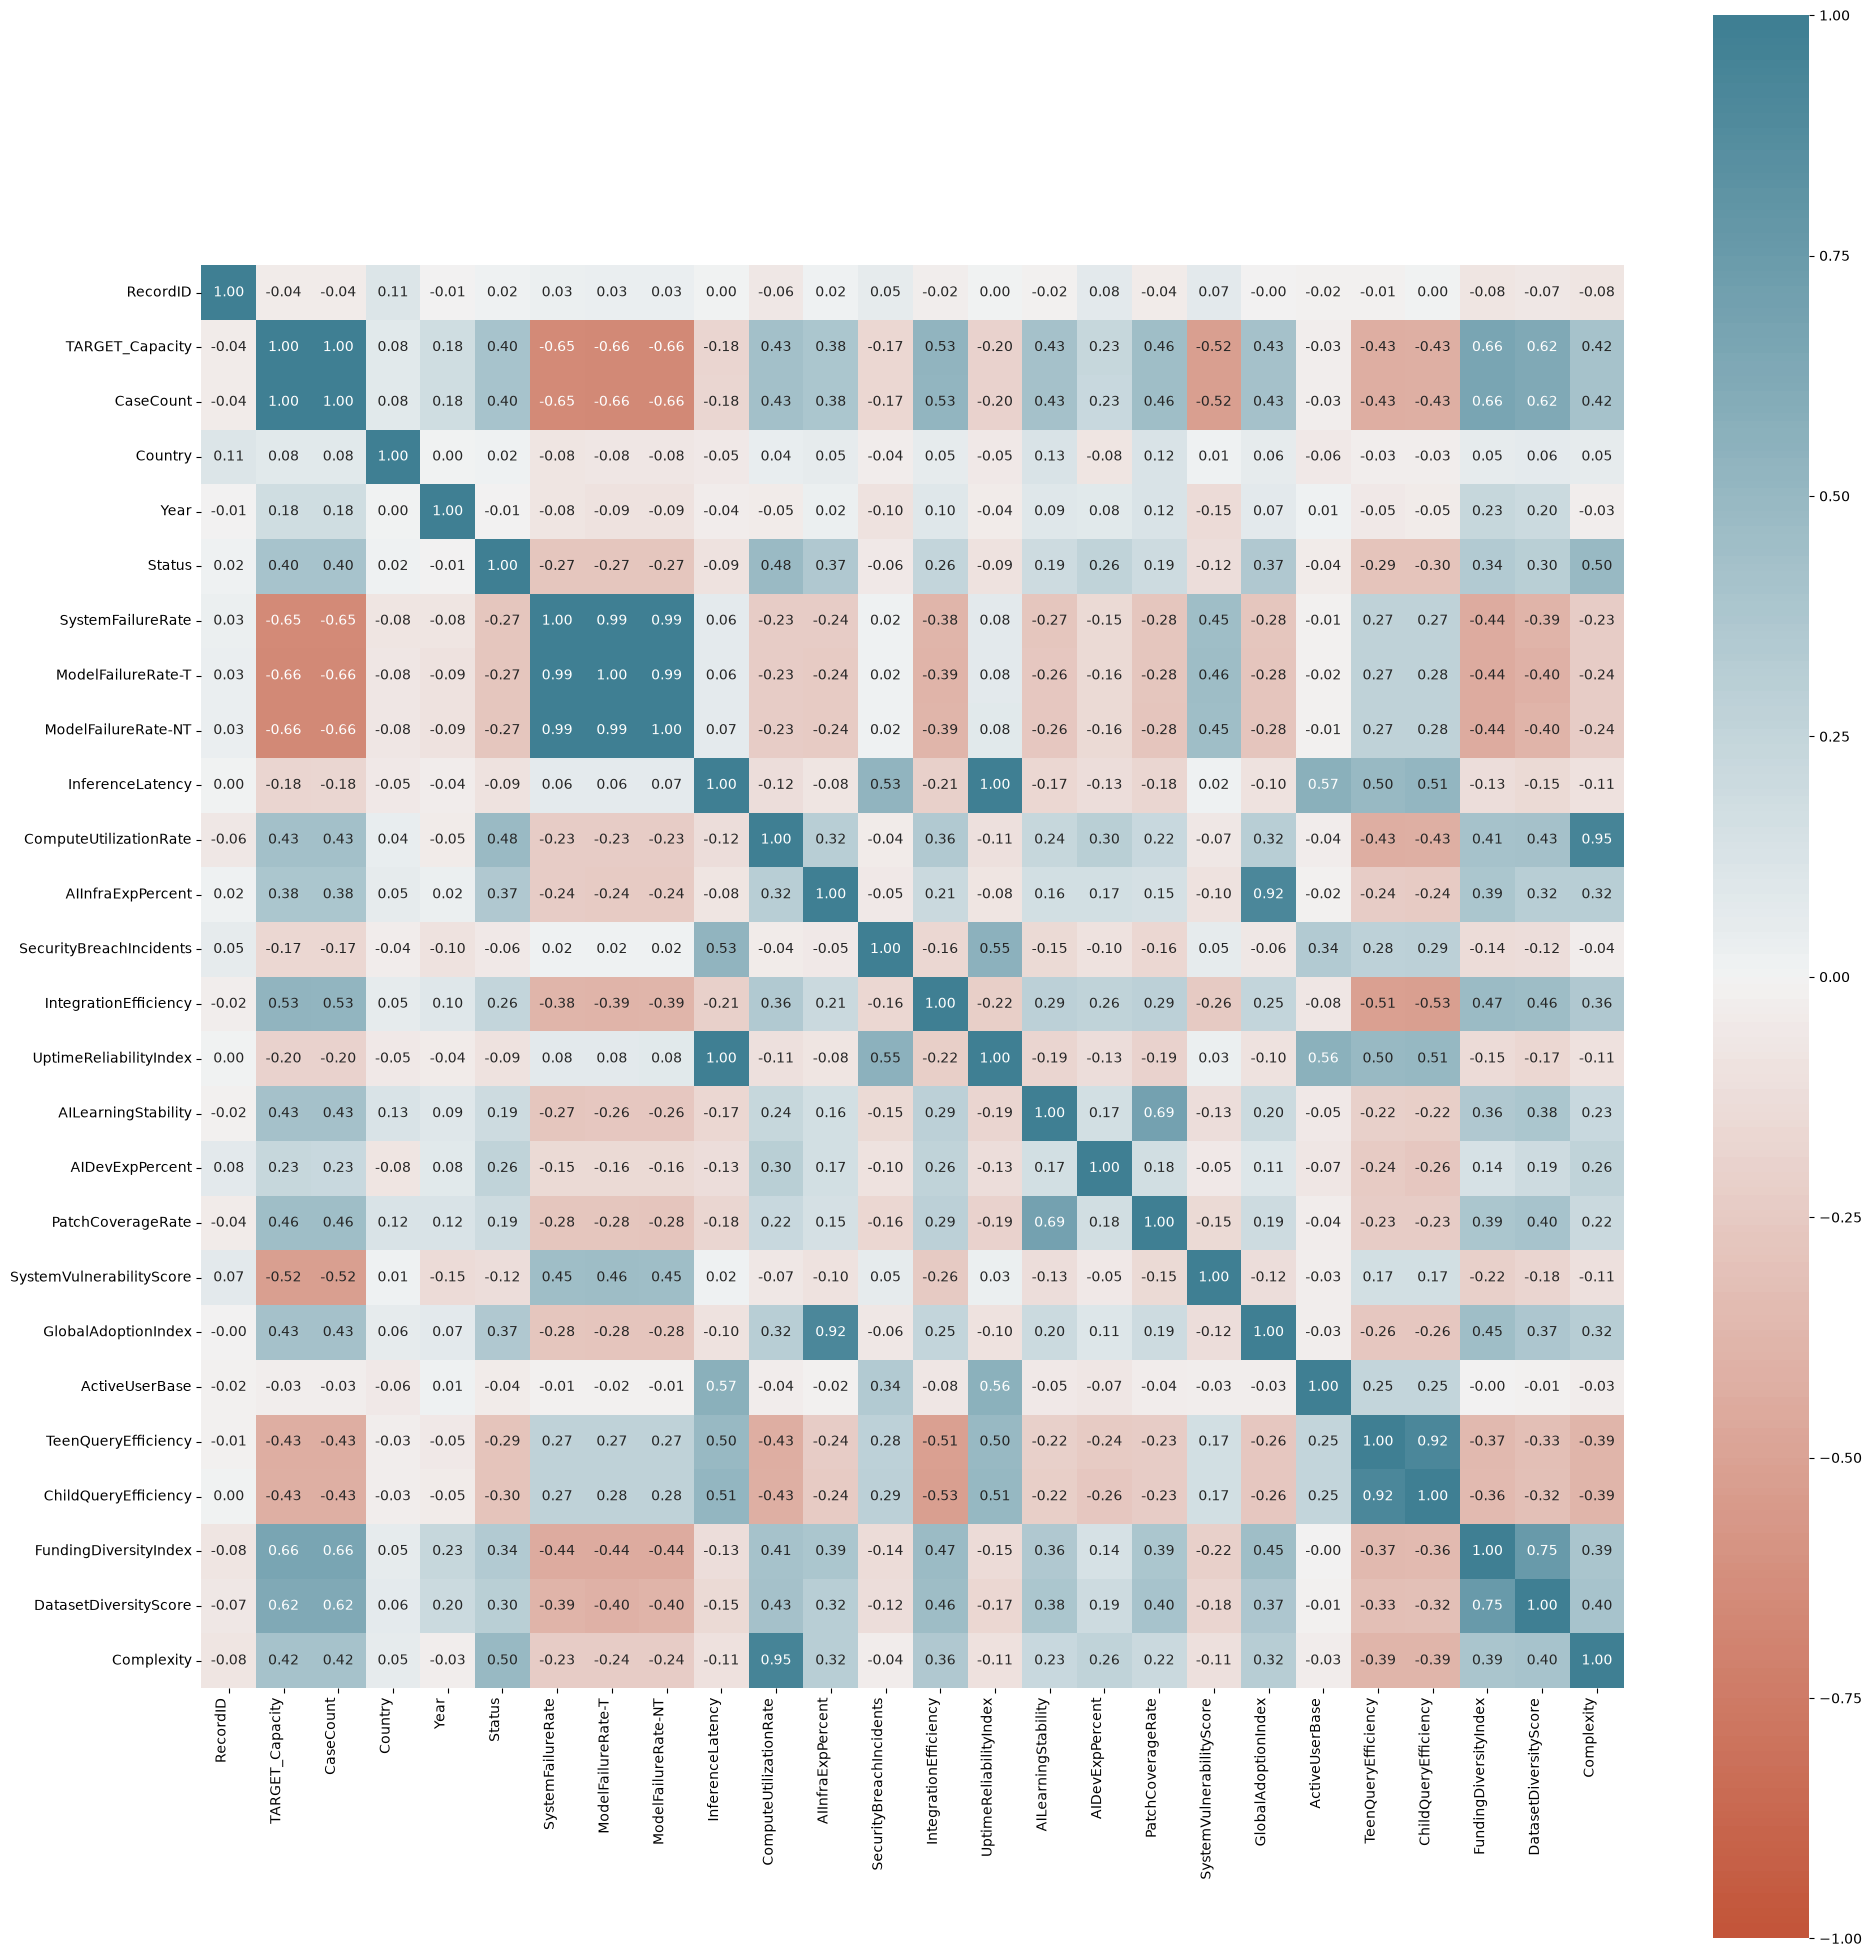

In [18]:
f, ax = plt.subplots(figsize=(20, 20))
corr = chatbot_data.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    fmt=".2f",
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
)

plt.tight_layout()
plt.show()

Drop rows with missing values

In [19]:
cleaned_data = chatbot_data.dropna()

Drop rows with Status different from 0 and 1

In [20]:
cleaned_data = cleaned_data[cleaned_data['Status'].isin([0, 1])]

Drop the 'RecordID' column as it is not useful for analysis

In [21]:
cleaned_data.drop(['RecordID'], axis=1, inplace=True)

Drop the 'CaseCount' column as it has high correlation with 'TARGET_Capacity' and may lead to data leakage in predictive modeling

In [22]:
cleaned_data.drop(['CaseCount'], axis=1, inplace=True)

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

target = "TARGET_Capacity"

X = cleaned_data.drop(columns=[target]).select_dtypes(include=[np.number]).copy()
X.drop(columns=["Country"], inplace=True)

X_const = add_constant(X)

vif_data = pd.DataFrame({
    "feature": X_const.columns,
    "VIF": [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
})

vif_data = vif_data[vif_data["feature"] != "const"].sort_values("VIF", ascending=False)
vif_data

,feature,VIF
11,UptimeReliabilityIndex,216.454877
6,InferenceLatency,215.753175
4,ModelFailureRate-T,74.583110
5,ModelFailureRate-NT,73.345561
3,SystemFailureRate,52.574510
7,ComputeUtilizationRate,12.578728
22,Complexity,12.104758
16,GlobalAdoptionIndex,7.621766
19,ChildQueryEfficiency,7.362434
8,AIInfraExpPercent,7.218995


Derived from the VIF analysis, we can see that some features have high multicollinearity. To address this, we will drop the following columns: 'InferenceLatency', 'ModelFailureRate-T', 'ModelFailureRate-NT', and 'Complexity'.

In [24]:
columns_to_drop = ['InferenceLatency', 'ModelFailureRate-T', 'ModelFailureRate-NT', 'Complexity']

cleaned_data.drop(columns=columns_to_drop, inplace=True)

In [25]:
cleaned_data.info()

<class 'pandas.DataFrame'>
Index: 2060 entries, 0 to 2070
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   TARGET_Capacity           2060 non-null   float64
 1   Country                   2060 non-null   int64  
 2   Year                      2060 non-null   float64
 3   Status                    2060 non-null   int64  
 4   SystemFailureRate         2060 non-null   int64  
 5   ComputeUtilizationRate    2060 non-null   float64
 6   AIInfraExpPercent         2060 non-null   float64
 7   SecurityBreachIncidents   2060 non-null   int64  
 8   IntegrationEfficiency     2060 non-null   float64
 9   UptimeReliabilityIndex    2060 non-null   int64  
 10  AILearningStability       2060 non-null   int64  
 11  AIDevExpPercent           2060 non-null   float64
 12  PatchCoverageRate         2060 non-null   float64
 13  SystemVulnerabilityScore  2060 non-null   float64
 14  GlobalAdoptionIndex     

### Split the data into training and testing sets

In [26]:
from sklearn.model_selection import train_test_split

target = "TARGET_Capacity"

X = cleaned_data.drop(columns=[target])
y = cleaned_data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)